In [5]:
import pandas as pd
import numpy as np
import shap
import pickle
import joblib

In [8]:
X_final = np.load("../data/X_final.npy")
X_tab = np.load("../data/X_tab.npy")
X_gnn = np.load("../data/X_gnn.npy")

tabular_feature_names = joblib.load("../data/tabular_feature_names.pkl")

gnn_feature_names = [f"gnn_emb_{i}" for i in range(X_gnn.shape[1])]

feature_names = tabular_feature_names + gnn_feature_names

In [9]:
import pickle
with open("models/hybrid_xgb.pkl", "rb") as f:
    xgb_model = pickle.load(f)

In [2]:
import shap
explainer = shap.TreeExplainer(xgb_model)

c:\Users\Diya\Desktop\fraud_ml\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
shap_values = explainer.shap_values(X_final)

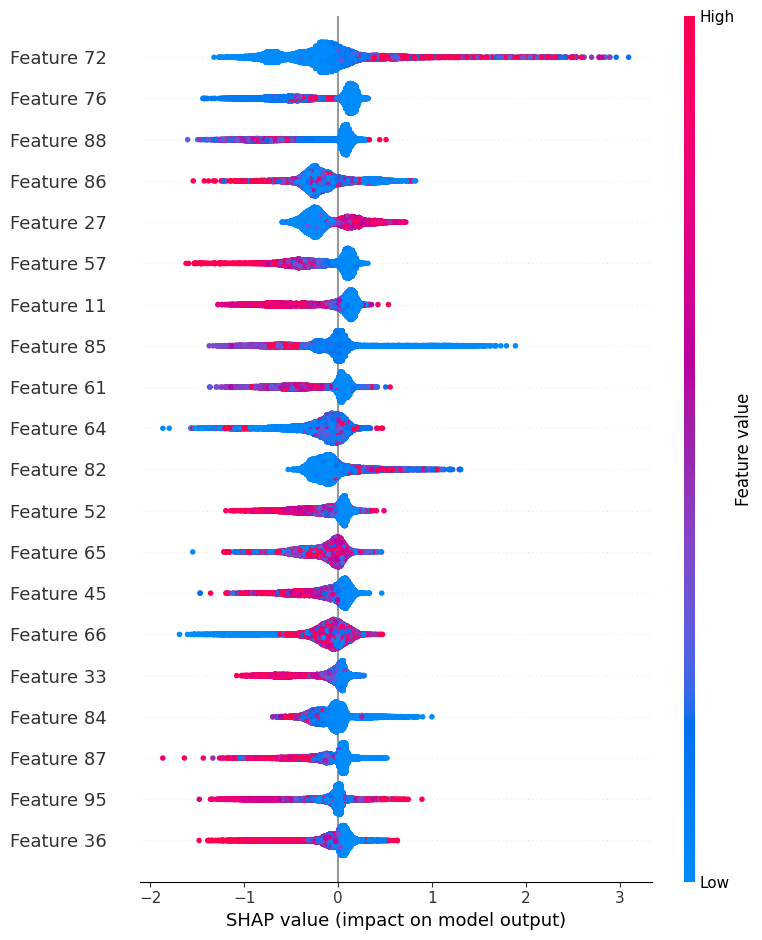

In [12]:
shap.summary_plot(shap_values, X_final)

In [14]:
import shap
shap.initjs()

i = 10  # example transaction

shap.force_plot(
    explainer.expected_value,
    shap_values[i],
    X_final[i]
)

In [15]:
feature_names = (
    tabular_feature_names + 
    [f"gnn_emb_{i}" for i in range(X_gnn.shape[1])]
)

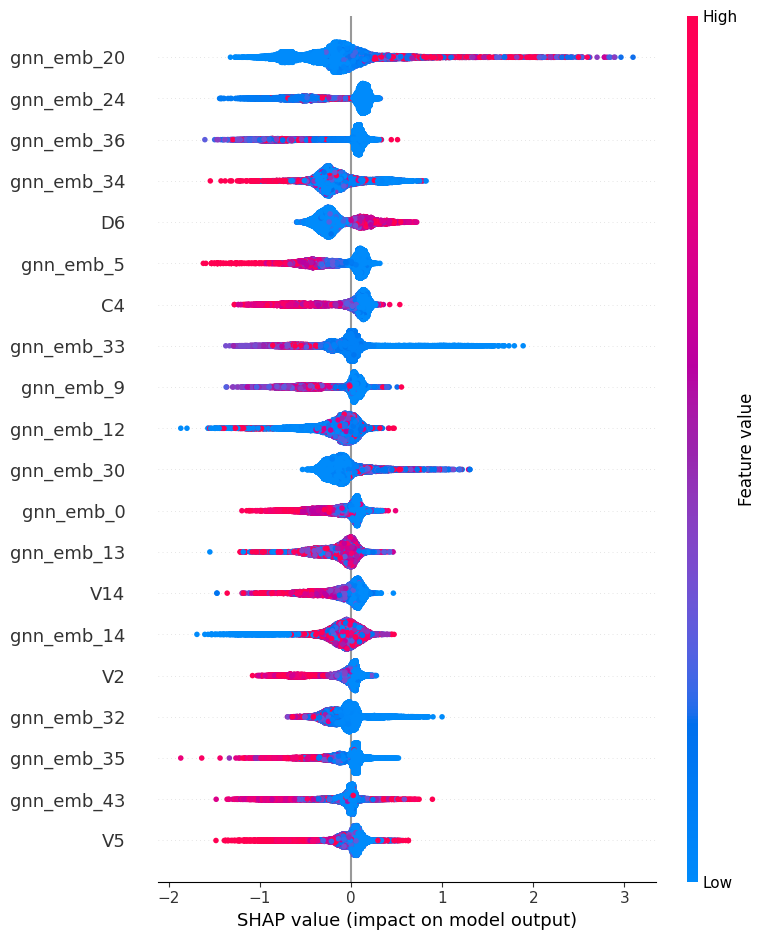

In [16]:
shap.summary_plot(shap_values, X_final, feature_names=feature_names)

In [17]:
import joblib
joblib.dump(explainer, "models/shap_explainer.pkl")

['models/shap_explainer.pkl']

In [1]:
import numpy as np

X_final = np.load("data/X_final.npy")
print("X_final shape:", X_final.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'data/X_final.npy'